<a href="https://colab.research.google.com/github/saverin0/Change-Detection-Using-Dinov3/blob/main/05_levir_cd_bitemporal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Change Detection with DINOv3
## Part 5: A Second Dataset, LEVIR-CD (bi-temporal pairs)

### What this notebook does
Parts 1–4 detect building change in **SpaceNet-7**: 4 m satellite imagery, monthly series, sparse and noisy change. This notebook applies the same recipe, frozen DINOv3 SAT-493M features plus a small trained head, to **LEVIR-CD**, the standard benchmark for bi-temporal building change detection, to see how the method behaves on a very different kind of data.

| | SpaceNet-7 (Parts 1–4) | LEVIR-CD (this notebook) |
|---|---|---|
| Imagery | Planet, ~4 m/px, 1024 px tiles (~4 km) | Google Earth, **0.5 m/px**, 1024 px tiles (~0.5 km) |
| Time | 18–26 monthly frames per location | **Two dates** per pair, 5–14 years apart |
| Labels | Footprints per month, cloud artifacts | Clean binary change mask per pair |
| Change pixels | ~0.3% | ~4–5% |
| Pairs | 60 locations | 445 train / 64 val / 128 test |

### Pipeline
```
Mount Drive ─► Install deps ─► Config ─► GPU ─► Hugging Face login ─► Download LEVIR-CD (Kaggle, cached on Drive)
     ─► Build pairs & look at samples ─► Load DINOv3 ─► Fit PCA on training images ─► Extract features (resumable)
     ─► Load features + masks into RAM ─► Define heads ─► Train both heads ─► Test-set evaluation ─► Figures
```

### Two heads, same features
1. **Difference head (baseline):** `[x_before, x_after, x_after − x_before]` → decoder to 128×128. This is the pair branch of the Part 3 model without the temporal transformer (there are only two frames).
2. **Cross-attention head:** before the difference, every patch of the *after* image attends to all patches of the *before* image (the `xattn` variant from Part 3).

Both are trained identically, the threshold is chosen on validation, and the **test split is scored once**.

### Before you run
1. **GPU runtime** (T4 is enough) and **`HF_TOKEN`** in Colab Secrets (see Part 2).
2. **The dataset zip.** If you already have LEVIR-CD, place the zip at `MyDrive/datasets/levir_cd_cache/levir-cd.zip` and nothing else is needed. Otherwise add Kaggle credentials to Colab Secrets, `KAGGLE_USERNAME` and `KAGGLE_KEY` (kaggle.com → Settings → API → Create new token gives a `kaggle.json` with both), and the ~2.6 GB dataset `mdrifaturrahman33/levir-cd` is downloaded once and kept on Drive.
3. **Drive space:** ~2.6 GB for the zip and ~2.7 GB for features.

> **On the numbers:** published LEVIR-CD results (F1 ≈ 0.90) are pixel-level at 1024×1024 with fully trained networks. Here the head predicts at **128×128 (8 m cells)** on frozen features, so the scores are not directly comparable with the leaderboard. They *are* comparable with the SpaceNet-7 runs in this repo, which use the same grid and metrics.

## Step 1: Mount Google Drive

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Install dependencies and import libraries

`transformers` ≥ 4.56 (DINOv3 support) and the `kaggle` client are installed or upgraded if needed. Images are PNGs, so no rasterio this time.

In [2]:
import importlib.metadata
import importlib.util
import subprocess
import sys


def installed_version(package):
    try:
        return tuple(int(part) for part in importlib.metadata.version(package).split(".")[:2])
    except importlib.metadata.PackageNotFoundError:
        return None


to_install = []
if (installed_version("transformers") or (0, 0)) < (4, 56):
    to_install.append("transformers>=4.56")
if importlib.util.find_spec("kaggle") is None:
    to_install.append("kaggle")
if to_install:
    print(f"Installing: {', '.join(to_install)}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", *to_install])

import json
import math
import os
import random
import shutil
import time
import zipfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.checkpoint import checkpoint
from tqdm.auto import tqdm

print(f"transformers {importlib.metadata.version('transformers')} | torch {torch.__version__}")

transformers 5.16.1 | torch 2.11.0+cu128


## Step 3: Configuration

Everything for this dataset lives under its own Drive folder, `datasets/levir_cd_cache/`, separate from the SpaceNet-7 cache.

| Setting | Value | Why |
|---|---|---|
| `FEATURE_IMAGE_SIZE` / `PCA_DIM` | 1024 / 256 | Same as Part 2: 64×64 patches of 8 m, PCA to keep features ~2.7 GB |
| `OUTPUT_RES` | 128 | Same target grid as SpaceNet-7 (8 m cells here) |
| `BATCH_SIZE` | 8 pairs | ~50 frames per step, similar to Part 3 |
| `EPOCHS` / `EARLY_STOP_PATIENCE` | 40 / 8 | Short epochs (56 steps), stop when validation F1 stalls |
| `LEARNING_RATE` / `WEIGHT_DECAY` / `DROPOUT` | 3e-4 / 0.05 / 0.2 | As in Part 3 |

In [3]:
MODEL_NAME = "facebook/dinov3-vitl16-pretrain-sat493m"
KAGGLE_DATASET = "mdrifaturrahman33/levir-cd"

CACHE_DIR = Path("/content/drive/MyDrive/datasets/levir_cd_cache")
LOCAL_DATA = Path("/content/levir_cd")
# Optional: path to a LEVIR-CD zip elsewhere on your Drive, used if the cache has none. None = cache or Kaggle only.
EXISTING_ZIP = None
LOCAL_FEATURES = Path("/content/levir_features")

FEATURE_IMAGE_SIZE = 1024
PCA_DIM = 256
PATCH_SIZE = 16
OUTPUT_RES = 128
PCA_SAMPLE_EVERY_NTH_PAIR = 3

BATCH_SIZE = 8
EPOCHS = 40
EARLY_STOP_PATIENCE = 8
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 2
DROPOUT = 0.2
TRANSFORMER_DIM = 256
N_HEADS = 8
SEED = 42

FEATURES_DIR = CACHE_DIR / f"features_{FEATURE_IMAGE_SIZE}_pca{PCA_DIM}"
PCA_PATH = FEATURES_DIR / "pca.npz"
RESULTS_DIR = CACHE_DIR / "training"
for folder in (FEATURES_DIR, RESULTS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

GRID = FEATURE_IMAGE_SIZE // PATCH_SIZE
N_PATCHES = GRID ** 2
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f"Features: {FEATURES_DIR}\nResults: {RESULTS_DIR}\nGrid: {GRID}x{GRID} -> targets {OUTPUT_RES}x{OUTPUT_RES}")

Features: /content/drive/MyDrive/datasets/levir_cd_cache/features_1024_pca256
Results: /content/drive/MyDrive/datasets/levir_cd_cache/training
Grid: 64x64 -> targets 128x128


## Step 4: Check the GPU

Feature extraction and training both need a GPU. Extraction runs 8 images per batch at 1024 px (4,101 tokens each) with memory-efficient attention, as in Part 2.

In [4]:
if not torch.cuda.is_available():
    raise RuntimeError("No GPU found. In Colab: Runtime -> Change runtime type -> T4 GPU, then run all cells again.")
device = torch.device("cuda")
gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
EXTRACT_BATCH = 8 if gpu_memory_gb >= 14 else 4
print(f"GPU: {torch.cuda.get_device_name()} ({gpu_memory_gb:.1f} GB) | extraction batch: {EXTRACT_BATCH}")

GPU: Tesla T4 (15.6 GB) | extraction batch: 8


## Step 5: Log in to Hugging Face

The DINOv3 weights are gated. The token is read from Colab Secrets (`HF_TOKEN`) and never written into the notebook.

In [5]:
from google.colab import userdata
from huggingface_hub import login

try:
    hf_token = userdata.get("HF_TOKEN")
except Exception as error:
    raise RuntimeError("Could not read the HF_TOKEN secret. Add it under the key icon and enable notebook access.") from error
login(token=hf_token, add_to_git_credential=False)
del hf_token
print("Logged in to Hugging Face.")

Logged in to Hugging Face.


## Step 6: Get LEVIR-CD

The zip is looked for in this order, and the first source found is used:
1. **The project cache** on Drive, `MyDrive/datasets/levir_cd_cache/levir-cd.zip`. If you already have the LEVIR-CD zip, put it there under that name and nothing is downloaded.
2. **A copy elsewhere on your Drive**, if you set `EXISTING_ZIP` in Step 3 (for example a zip in a Drive-for-desktop backup, which Colab mounts under `/content/drive/Othercomputers/`). It's copied into the project cache so later runs don't depend on it.
3. **Kaggle**, as a last resort: needs `KAGGLE_USERNAME` and `KAGGLE_KEY` in Colab Secrets. The credentials go through environment variables only for the download call and are deleted afterwards.

Either way the zip ends up unzipped on Colab's local disk, where reading the 1,274 PNGs is fast.

In [6]:
zip_path = CACHE_DIR / "levir-cd.zip"
local_zip = LOCAL_DATA / "levir-cd.zip"
LOCAL_DATA.mkdir(parents=True, exist_ok=True)

if not any(LOCAL_DATA.rglob("label")):
    if not zip_path.exists() and EXISTING_ZIP is not None and EXISTING_ZIP.exists():
        print(f"Found an existing copy at {EXISTING_ZIP} ({EXISTING_ZIP.stat().st_size / 1e9:.1f} GB); copying it into the project cache...")
        shutil.copyfile(EXISTING_ZIP, zip_path)
    if zip_path.exists():
        print(f"Copying cached zip from Drive ({zip_path.stat().st_size / 1e9:.1f} GB)...")
        shutil.copyfile(zip_path, local_zip)
    else:
        print(f"No zip at {zip_path}" + (f" or {EXISTING_ZIP}" if EXISTING_ZIP else "") + ". Downloading from Kaggle.")
        try:
            os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
            os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
        except Exception as error:
            raise RuntimeError("Add KAGGLE_USERNAME and KAGGLE_KEY to Colab Secrets (from your kaggle.json).") from error
        print(f"Downloading {KAGGLE_DATASET} from Kaggle...")
        subprocess.check_call(["kaggle", "datasets", "download", "-d", KAGGLE_DATASET, "-p", str(LOCAL_DATA)])
        os.environ.pop("KAGGLE_USERNAME", None)
        os.environ.pop("KAGGLE_KEY", None)
        downloaded = next(LOCAL_DATA.glob("*.zip"))
        downloaded.rename(local_zip)
        print("Saving the zip to Drive for next time...")
        shutil.copyfile(local_zip, zip_path)
    print("Unzipping...")
    with zipfile.ZipFile(local_zip) as archive:
        archive.extractall(LOCAL_DATA)
    local_zip.unlink()

split_dirs = {}
for label_dir in LOCAL_DATA.rglob("label"):
    split = label_dir.parent.name.lower()
    if split in ("train", "val", "test") and (label_dir.parent / "A").is_dir():
        split_dirs[split] = label_dir.parent
if "train" not in split_dirs or "test" not in split_dirs:
    raise FileNotFoundError(f"Could not find train/test folders with A, B, label under {LOCAL_DATA}")
print({k: str(v) for k, v in split_dirs.items()})

Copying cached zip from Drive (2.5 GB)...
Unzipping...
{'val': '/content/levir_cd/LEVIR CD/val', 'test': '/content/levir_cd/LEVIR CD/test', 'train': '/content/levir_cd/LEVIR CD/train'}


## Step 7: Build the pairs and look at a few

Each pair is `A/<name>.png` (before), `B/<name>.png` (after), and `label/<name>.png` (binary change mask). The cell counts pairs and change pixels per split and shows the four training pairs with the most change. LEVIR-CD's val split is used for model selection and the threshold; if it were missing, 15% of train would be held out instead.

train:  445 pairs | change pixels 4.59% | pairs with no change 47
val  :   64 pairs | change pixels 4.20% | pairs with no change 8
test :  128 pairs | change pixels 5.09% | pairs with no change 10


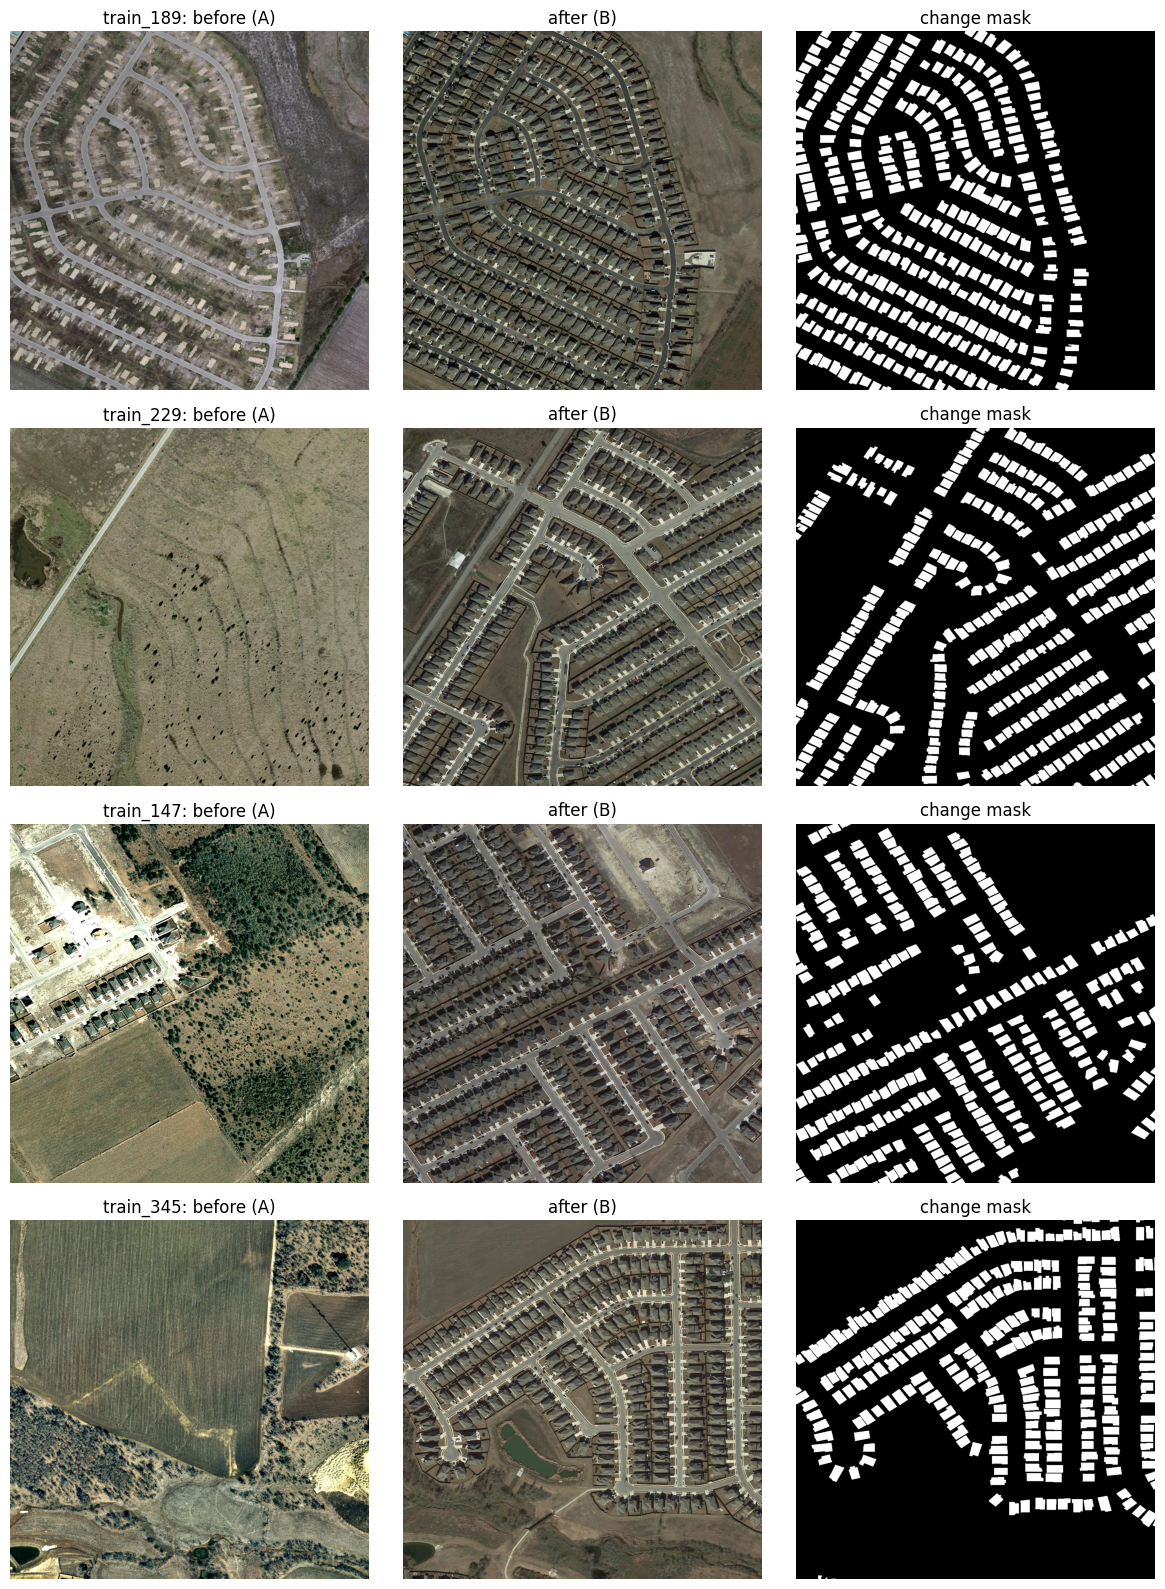

In [7]:
def build_pairs(split_dir):
    pairs = []
    for a in sorted((split_dir / "A").glob("*.png")):
        b, mask = split_dir / "B" / a.name, split_dir / "label" / a.name
        if b.exists() and mask.exists():
            pairs.append({"name": a.stem, "a": a, "b": b, "mask": mask})
    return pairs


pairs = {split: build_pairs(folder) for split, folder in split_dirs.items()}
if "val" not in pairs:
    rng = random.Random(SEED)
    shuffled = pairs["train"][:]
    rng.shuffle(shuffled)
    n_val = max(1, round(0.15 * len(shuffled)))
    pairs["val"], pairs["train"] = shuffled[:n_val], shuffled[n_val:]

def change_fraction(p):
    return float((np.array(Image.open(p["mask"]).convert("L")) > 127).mean())


with ThreadPoolExecutor(8) as pool:
    for split in ("train", "val", "test"):
        fractions = list(pool.map(change_fraction, pairs[split]))
        for p, frac in zip(pairs[split], fractions):
            p["change_fraction"] = frac
        print(f"{split:5s}: {len(pairs[split]):4d} pairs | change pixels {100 * np.mean(fractions):.2f}% | "
              f"pairs with no change {sum(f == 0 for f in fractions)}")

samples = sorted(pairs["train"], key=lambda p: -p["change_fraction"])[:4]
fig, axes = plt.subplots(len(samples), 3, figsize=(12, 4 * len(samples)))
for row, p in enumerate(samples):
    for col, (path, title) in enumerate([(p["a"], "before (A)"), (p["b"], "after (B)"), (p["mask"], "change mask")]):
        axes[row, col].imshow(Image.open(path), cmap="gray" if col == 2 else None)
        axes[row, col].set_title(f"{p['name']}: {title}" if col == 0 else title)
        axes[row, col].axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_pairs.png", dpi=120)
plt.show()

## Step 8: Load DINOv3 and define the extraction helpers

Identical to Part 2: fp16 autocast, SDPA attention, the processor's satellite normalization values, our own resizing to 1024 px, and PCA applied on the GPU. `load_image` reads a PNG and resizes it with bilinear filtering.

In [8]:
from transformers import AutoImageProcessor, AutoModel

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
try:
    dino = AutoModel.from_pretrained(MODEL_NAME, attn_implementation="sdpa")
except (ValueError, TypeError):
    dino = AutoModel.from_pretrained(MODEL_NAME)
dino = dino.to(device).eval()
HIDDEN_DIM = dino.config.hidden_size
N_REGISTER_TOKENS = getattr(dino.config, "num_register_tokens", 0)
PIXEL_MEAN = torch.tensor(processor.image_mean, device=device).view(1, 3, 1, 1)
PIXEL_STD = torch.tensor(processor.image_std, device=device).view(1, 3, 1, 1)
print(f"Loaded {MODEL_NAME}: hidden {HIDDEN_DIM}, attention {getattr(dino.config, '_attn_implementation', '?')}")


def load_image(path, size=FEATURE_IMAGE_SIZE):
    img = Image.open(path).convert("RGB").resize((size, size), Image.BILINEAR)
    return np.asarray(img).transpose(2, 0, 1)


@torch.inference_mode()
def patch_tokens(images):
    pixels = torch.from_numpy(images).to(device).float().div_(255)
    pixels = (pixels - PIXEL_MEAN) / PIXEL_STD
    with torch.autocast(device_type="cuda", dtype=torch.float16):
        tokens = dino(pixel_values=pixels).last_hidden_state
    if tokens.shape[1] != 1 + N_REGISTER_TOKENS + N_PATCHES:
        raise RuntimeError(f"Unexpected token count {tokens.shape[1]}")
    return tokens[:, 1 + N_REGISTER_TOKENS:, :].float()


pca_mean = pca_components = None


@torch.inference_mode()
def to_features(patches):
    if pca_components is not None:
        patches = (patches - pca_mean) @ pca_components.T
    return patches.reshape(len(patches), GRID, GRID, -1).to(torch.float16).cpu().numpy()

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/745 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.21GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Loaded facebook/dinov3-vitl16-pretrain-sat493m: hidden 1024, attention sdpa


## Step 9: Fit (or load) the PCA on training images

As in Part 2: the covariance of the 1024-dim patch vectors is accumulated over every third **training** pair (both dates), the top 256 eigenvectors are kept, and the result is saved to `pca.npz`. On later runs the saved PCA is loaded so features stay consistent.

In [9]:
if PCA_PATH.exists():
    with np.load(PCA_PATH) as saved:
        pca_mean = torch.from_numpy(saved["mean"]).to(device)
        pca_components = torch.from_numpy(saved["components"]).to(device)
        print(f"Loaded PCA: {PCA_DIM} dims keep {100 * float(saved['explained_variance_ratio'].sum()):.1f}% of the variance")
else:
    sample_paths = [path for p in pairs["train"][::PCA_SAMPLE_EVERY_NTH_PAIR] for path in (p["a"], p["b"])]
    total = torch.zeros(HIDDEN_DIM, dtype=torch.float64, device=device)
    cross = torch.zeros(HIDDEN_DIM, HIDDEN_DIM, dtype=torch.float64, device=device)
    n_vectors = 0
    with ThreadPoolExecutor(4) as pool:
        for i in tqdm(range(0, len(sample_paths), EXTRACT_BATCH), desc=f"Fitting PCA on {len(sample_paths)} images"):
            images = np.stack(list(pool.map(load_image, sample_paths[i:i + EXTRACT_BATCH])))
            vectors = patch_tokens(images).reshape(-1, HIDDEN_DIM)
            total += vectors.sum(0, dtype=torch.float64)
            cross += (vectors.T @ vectors).double()
            n_vectors += len(vectors)
    mean = total / n_vectors
    eigenvalues, eigenvectors = torch.linalg.eigh(cross / n_vectors - torch.outer(mean, mean))
    order = torch.argsort(eigenvalues, descending=True)
    eigenvalues, eigenvectors = eigenvalues[order].clamp(min=0), eigenvectors[:, order]
    explained = (eigenvalues / eigenvalues.sum())[:PCA_DIM]
    pca_mean, pca_components = mean.float(), eigenvectors[:, :PCA_DIM].T.contiguous().float()
    np.savez(PCA_PATH, mean=pca_mean.cpu().numpy(), components=pca_components.cpu().numpy(),
             explained_variance_ratio=explained.cpu().numpy(), image_size=FEATURE_IMAGE_SIZE, model=MODEL_NAME)
    print(f"Fitted PCA on {n_vectors:,} vectors: {PCA_DIM} dims keep {100 * float(explained.sum()):.1f}% of the variance")

Fitting PCA on 298 images:   0%|          | 0/38 [00:00<?, ?it/s]

Fitted PCA on 1,220,608 vectors: 256 dims keep 87.9% of the variance


## Step 10: Extract features for every pair (resumable)

For each pair, both images go through DINOv3 and PCA, and `features_a`, `features_b` (each `(64, 64, 256)` float16) are saved to one `.npz` per pair, uploaded to Drive in the background. Pairs that already have a file are skipped, so the step resumes after a disconnect. ~1,300 images take about 7 minutes on a T4.

In [10]:
LOCAL_FEATURES.mkdir(parents=True, exist_ok=True)


def upload(local_file, split):
    target_dir = FEATURES_DIR / split
    target_dir.mkdir(exist_ok=True)
    partial = target_dir / f"{local_file.name}.partial"
    shutil.copyfile(local_file, partial)
    partial.replace(target_dir / local_file.name)
    local_file.unlink()


todo = [(split, p) for split in ("train", "val", "test") for p in pairs[split]
        if not (FEATURES_DIR / split / f"{p['name']}.npz").exists()]
print(f"Pairs to extract: {len(todo)} | already done: {sum(len(v) for v in pairs.values()) - len(todo)}")

start = time.perf_counter()
uploads = []
with ThreadPoolExecutor(4) as load_pool, ThreadPoolExecutor(1) as upload_pool:
    for i in tqdm(range(0, len(todo), EXTRACT_BATCH // 2), desc="Extracting"):
        chunk = todo[i:i + EXTRACT_BATCH // 2]
        paths = [path for _, p in chunk for path in (p["a"], p["b"])]
        feats = to_features(patch_tokens(np.stack(list(load_pool.map(load_image, paths)))))
        for j, (split, p) in enumerate(chunk):
            local_file = LOCAL_FEATURES / f"{p['name']}.npz"
            np.savez(local_file, features_a=feats[2 * j], features_b=feats[2 * j + 1])
            uploads.append(upload_pool.submit(upload, local_file, split))
    for future in tqdm(as_completed(uploads), total=len(uploads), desc="Uploading"):
        future.result()
print(f"Done in {(time.perf_counter() - start) / 60:.1f} min")

del dino
torch.cuda.empty_cache()

Pairs to extract: 637 | already done: 0


Extracting:   0%|          | 0/160 [00:00<?, ?it/s]

Uploading:   0%|          | 0/637 [00:00<?, ?it/s]

Done in 8.1 min


## Step 11: Load features and masks into RAM

All features (~2.7 GB float16) and the change masks, max-pooled to 128×128 so that any positive pixel inside a cell marks the cell (as in Part 3), are loaded with 6 threads from Drive.

In [11]:
def load_pair(split, p):
    with np.load(FEATURES_DIR / split / f"{p['name']}.npz") as f:
        a, b = torch.from_numpy(f["features_a"]), torch.from_numpy(f["features_b"])
    mask = torch.from_numpy((np.array(Image.open(p["mask"]).convert("L")) > 127).astype(np.float32))
    target = F.adaptive_max_pool2d(mask[None, None], OUTPUT_RES)[0, 0].to(torch.uint8)
    return {"a": a, "b": b, "target": target, "name": p["name"]}


data = {}
with ThreadPoolExecutor(6) as pool:
    for split in ("train", "val", "test"):
        data[split] = list(tqdm(pool.map(lambda p: load_pair(split, p), pairs[split]), total=len(pairs[split]), desc=split))
FEATURE_DIM = data["train"][0]["a"].shape[-1]
for split, items in data.items():
    positives = np.mean([item["target"].float().mean().item() for item in items])
    print(f"{split:5s}: {len(items)} pairs | change cells {100 * positives:.1f}%")

train:   0%|          | 0/445 [00:00<?, ?it/s]

val:   0%|          | 0/64 [00:00<?, ?it/s]

test:   0%|          | 0/128 [00:00<?, ?it/s]

train: 445 pairs | change cells 7.0%
val  : 64 pairs | change cells 6.4%
test : 128 pairs | change cells 7.8%


## Step 12: Batching, augmentation, and the two heads

`make_batch` stacks pairs into `(B, 64, 64, 256)` tensors for before and after plus `(B, 128, 128)` targets. Training pairs get a random 90° rotation and flip, applied identically to both dates and the mask.

Both heads share the same building blocks as Part 3 (`Decoder`, `SpatialCrossAttention`, the pair projection `[x_a, x_b, x_b − x_a]`); the only difference is whether cross-attention runs before the difference. Gradient checkpointing keeps memory low.

In [12]:
def augment(a, b, target):
    k = random.randint(0, 3)
    flip = random.random() < 0.5
    out = []
    for t in (a, b, target):
        t = torch.rot90(t, k, dims=(0, 1))
        out.append(t.flip(1) if flip else t)
    return out


def make_batch(items, augment_data=False):
    a = torch.zeros(len(items), GRID, GRID, FEATURE_DIM, dtype=torch.float16)
    b = torch.zeros_like(a)
    target = torch.zeros(len(items), OUTPUT_RES, OUTPUT_RES, dtype=torch.uint8)
    for i, item in enumerate(items):
        fa, fb, t = (augment(item["a"], item["b"], item["target"]) if augment_data else (item["a"], item["b"], item["target"]))
        a[i], b[i], target[i] = fa, fb, t
    return {k: v.to(device, non_blocking=True) for k, v in {"a": a, "b": b, "target": target}.items()}


def batches(items, batch_size, shuffle=False, augment_data=False):
    order = list(items)
    if shuffle:
        random.shuffle(order)
    for i in range(0, len(order), batch_size):
        yield make_batch(order[i:i + batch_size], augment_data)


def sincos_position_encoding(grid, dim):
    quarter = dim // 4
    omega = 1.0 / (10000 ** (torch.arange(quarter, dtype=torch.float32) / quarter))
    ys, xs = torch.meshgrid(torch.arange(grid, dtype=torch.float32), torch.arange(grid, dtype=torch.float32), indexing="ij")
    out = []
    for coord in (ys.flatten(), xs.flatten()):
        angles = coord[:, None] * omega[None, :]
        out += [torch.sin(angles), torch.cos(angles)]
    return torch.cat(out, dim=1)


class SpatialCrossAttention(nn.Module):
    def __init__(self, dim, n_heads, grid, dropout):
        super().__init__()
        self.n_heads, self.dropout = n_heads, dropout
        self.register_buffer("pos", sincos_position_encoding(grid, dim), persistent=False)
        self.norm_next, self.norm_prev = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.to_q, self.to_kv, self.out = nn.Linear(dim, dim), nn.Linear(dim, 2 * dim), nn.Linear(dim, dim)

    def forward(self, x_prev, x_next, pairs_per_chunk=4):
        P, D, H, W = x_prev.shape
        prev, nxt = x_prev.flatten(2).transpose(1, 2), x_next.flatten(2).transpose(1, 2)
        q = self.to_q(self.norm_next(nxt) + self.pos)
        k, v = self.to_kv(self.norm_prev(prev) + self.pos).chunk(2, dim=-1)
        heads = lambda t: t.reshape(len(t), H * W, self.n_heads, D // self.n_heads).transpose(1, 2)
        attended = torch.cat([
            F.scaled_dot_product_attention(heads(q[i:i + pairs_per_chunk]), heads(k[i:i + pairs_per_chunk]),
                                           heads(v[i:i + pairs_per_chunk]), dropout_p=self.dropout if self.training else 0.0)
            for i in range(0, P, pairs_per_chunk)])
        attended = self.out(attended.transpose(1, 2).reshape(P, H * W, D))
        return (prev + attended).transpose(1, 2).reshape(P, D, H, W)


class Decoder(nn.Module):
    def __init__(self, in_channels, grid, output_res):
        super().__init__()
        n_stages = int(math.log2(output_res // grid))
        layers, channels = [], in_channels
        for stage in range(n_stages):
            out_channels = 64 if stage == n_stages - 1 else max(64, channels // 2)
            layers += [nn.ConvTranspose2d(channels, out_channels, 4, stride=2, padding=1), nn.GroupNorm(8, out_channels), nn.GELU()]
            channels = out_channels
        layers += [nn.Conv2d(channels, channels, 3, padding=1), nn.GroupNorm(8, channels), nn.GELU(), nn.Conv2d(channels, 1, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


class BitemporalChangeHead(nn.Module):
    def __init__(self, feature_dim, dim, n_heads, dropout, grid, output_res, variant="baseline"):
        super().__init__()
        self.input_proj = nn.Sequential(nn.Linear(feature_dim, dim), nn.LayerNorm(dim), nn.GELU(), nn.Dropout(dropout))
        self.cross_attention = SpatialCrossAttention(dim, n_heads, grid, dropout) if variant == "xattn" else None
        self.pair_proj = nn.Sequential(nn.Linear(dim * 3, dim), nn.GELU())
        self.decoder = Decoder(dim, grid, output_res)

    def _maybe_checkpoint(self, module, *args):
        return checkpoint(module, *args, use_reentrant=False) if self.training else module(*args)

    def forward(self, a, b):
        if not torch.is_autocast_enabled(a.device.type):
            a, b = a.float(), b.float()
        xa = self._maybe_checkpoint(self.input_proj, a).permute(0, 3, 1, 2)
        xb = self._maybe_checkpoint(self.input_proj, b).permute(0, 3, 1, 2)
        if self.cross_attention is not None:
            xa = self._maybe_checkpoint(self.cross_attention, xa, xb)
        pairs = torch.cat([xa, xb, xb - xa], dim=1).permute(0, 2, 3, 1)
        pairs = self.pair_proj(pairs).permute(0, 3, 1, 2)
        return self._maybe_checkpoint(self.decoder, pairs)


for variant in ("baseline", "xattn"):
    m = BitemporalChangeHead(FEATURE_DIM, TRANSFORMER_DIM, N_HEADS, DROPOUT, GRID, OUTPUT_RES, variant)
    print(f"{variant:9s}: {sum(p.numel() for p in m.parameters()) / 1e6:.2f}M parameters")

baseline : 0.56M parameters
xattn    : 0.83M parameters


## Step 13: Loss, metrics, and the training function

The same Focal + Dice loss and threshold-sweep metrics as Part 3 (no cloud masks here, so every cell counts). `train_head` trains one variant with AdamW, warmup + cosine schedule, fp16 autocast, gradient clipping, and early stopping, keeps the epoch with the best validation F1, and returns its history.

In [13]:
class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, smooth=1.0):
        super().__init__()
        self.alpha, self.gamma, self.smooth = alpha, gamma, smooth

    def forward(self, logits, targets):
        logits, targets = logits.float(), targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal = (alpha_t * (1 - p_t) ** self.gamma * bce).mean()
        tp = (probs * targets).sum()
        dice = 1 - (2 * tp + self.smooth) / (probs.sum() + targets.sum() + self.smooth)
        return focal + dice


THRESHOLDS = torch.linspace(0.05, 0.95, 19)


class Counts:
    def __init__(self):
        self.tp = torch.zeros(len(THRESHOLDS), dtype=torch.float64)
        self.fp, self.fn = torch.zeros_like(self.tp), torch.zeros_like(self.tp)

    @torch.no_grad()
    def update(self, logits, targets):
        probs = torch.sigmoid(logits.float()).flatten()
        positive = targets.flatten().bool()
        predicted = probs[None, :] > THRESHOLDS.to(probs.device)[:, None]
        self.tp += (predicted & positive).sum(1).double().cpu()
        self.fp += (predicted & ~positive).sum(1).double().cpu()
        self.fn += (~predicted & positive).sum(1).double().cpu()

    def scores(self, i):
        tp, fp, fn = (float(v[i]) for v in (self.tp, self.fp, self.fn))
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        return {"threshold": round(float(THRESHOLDS[i]), 2), "precision": precision, "recall": recall, "f1": f1,
                "iou": tp / (tp + fp + fn) if tp + fp + fn else 0.0}

    def best(self):
        return max((self.scores(i) for i in range(len(THRESHOLDS))), key=lambda s: s["f1"])

    def at(self, threshold):
        return self.scores(int(torch.argmin((THRESHOLDS - threshold).abs())))


criterion = FocalDiceLoss()


@torch.no_grad()
def evaluate(model, items):
    model.eval()
    counts, total_loss, n = Counts(), 0.0, 0
    for batch in batches(items, BATCH_SIZE):
        with torch.autocast("cuda", dtype=torch.float16):
            logits = model(batch["a"], batch["b"])
        total_loss += criterion(logits, batch["target"]).item()
        counts.update(logits, batch["target"])
        n += 1
    return total_loss / n, counts


def train_head(variant):
    torch.manual_seed(SEED)
    random.seed(SEED)
    model = BitemporalChangeHead(FEATURE_DIM, TRANSFORMER_DIM, N_HEADS, DROPOUT, GRID, OUTPUT_RES, variant).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    steps_per_epoch = math.ceil(len(data["train"]) / BATCH_SIZE)
    total_steps, warmup = EPOCHS * steps_per_epoch, WARMUP_EPOCHS * steps_per_epoch
    lr_factor = lambda s: (s + 1) / warmup if s < warmup else 0.01 + 0.99 * 0.5 * (1 + math.cos(math.pi * min(1.0, (s - warmup) / max(1, total_steps - warmup))))
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_factor)
    scaler = torch.amp.GradScaler("cuda")
    history = {k: [] for k in ("epoch", "train_loss", "val_loss", "val_f1", "val_threshold")}
    best_f1, best_state, since_best = -1.0, None, 0

    print(f"\n=== {variant} ===")
    for epoch in range(EPOCHS):
        start = time.perf_counter()
        model.train()
        train_loss = 0.0
        for batch in batches(data["train"], BATCH_SIZE, shuffle=True, augment_data=True):
            with torch.autocast("cuda", dtype=torch.float16):
                logits = model(batch["a"], batch["b"])
            loss = criterion(logits, batch["target"])
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            train_loss += loss.item()
        val_loss, val_counts = evaluate(model, data["val"])
        best = val_counts.best()
        for key, value in [("epoch", epoch + 1), ("train_loss", train_loss / steps_per_epoch), ("val_loss", val_loss),
                           ("val_f1", best["f1"]), ("val_threshold", best["threshold"])]:
            history[key].append(value)
        improved = best["f1"] > best_f1
        if improved:
            best_f1, since_best = best["f1"], 0
            best_state = {"model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                          "epoch": epoch + 1, "threshold": best["threshold"], "val": best}
        else:
            since_best += 1
        print(f"Epoch {epoch + 1:3d} ({time.perf_counter() - start:3.0f}s) | train {history['train_loss'][-1]:.4f} | "
              f"val {val_loss:.4f} | val F1 {best['f1']:.4f}@{best['threshold']:.2f}{'  *' if improved else ''}")
        if since_best >= EARLY_STOP_PATIENCE:
            print(f"Early stopping after {epoch + 1} epochs.")
            break
    model.load_state_dict(best_state["model"])
    torch.save(best_state, RESULTS_DIR / f"{variant}_best.pt")
    return model, best_state, history

## Step 14: Train both heads and score the test split once

Each head trains for up to 40 short epochs (about 25 s each on a T4). The threshold with the best validation F1 is kept for each head, and the **test split** (128 pairs, never used before) is scored at that threshold. Results go to `levir_cd_cache/training/results.json`.

In [14]:
results, histories, models = {}, {}, {}
for variant in ("baseline", "xattn"):
    model, best_state, history = train_head(variant)
    test_loss, test_counts = evaluate(model, data["test"])
    results[variant] = {"best_epoch": best_state["epoch"], "epochs_trained": len(history["epoch"]),
                        "threshold": best_state["threshold"], "val": best_state["val"],
                        "test": test_counts.at(best_state["threshold"]), "test_loss": test_loss,
                        "parameters": sum(p.numel() for p in model.parameters())}
    histories[variant], models[variant] = history, model

summary = {"dataset": "LEVIR-CD", "features": FEATURES_DIR.name, "grid": GRID, "output_res": OUTPUT_RES,
           "pairs": {k: len(v) for k, v in pairs.items()}, "results": results, "history": histories}
(RESULTS_DIR / "results.json").write_text(json.dumps(summary, indent=2))

print(f"\n{'head':10s}{'params':>8s}{'best ep':>9s}{'thr':>6s}{'val F1':>8s}{'test P':>8s}{'test R':>8s}{'test F1':>9s}{'test IoU':>10s}")
for variant, r in results.items():
    t = r["test"]
    print(f"{variant:10s}{r['parameters'] / 1e6:>7.2f}M{r['best_epoch']:>9d}{r['threshold']:>6.2f}{r['val']['f1']:>8.3f}"
          f"{t['precision']:>8.3f}{t['recall']:>8.3f}{t['f1']:>9.3f}{t['iou']:>10.3f}")
print(f"\nSaved to {RESULTS_DIR / 'results.json'}")


=== baseline ===
Epoch   1 (  5s) | train 0.8107 | val 0.5819 | val F1 0.8148@0.65  *
Epoch   2 (  4s) | train 0.4752 | val 0.4138 | val F1 0.8696@0.55  *
Epoch   3 (  3s) | train 0.3414 | val 0.3032 | val F1 0.8785@0.70  *
Epoch   4 (  4s) | train 0.2650 | val 0.2389 | val F1 0.8832@0.55  *
Epoch   5 (  3s) | train 0.2100 | val 0.2017 | val F1 0.8883@0.55  *
Epoch   6 (  4s) | train 0.1792 | val 0.1768 | val F1 0.8947@0.55  *
Epoch   7 (  4s) | train 0.1629 | val 0.1681 | val F1 0.8933@0.70
Epoch   8 (  4s) | train 0.1500 | val 0.1559 | val F1 0.8971@0.50  *
Epoch   9 (  3s) | train 0.1439 | val 0.1478 | val F1 0.8998@0.55  *
Epoch  10 (  4s) | train 0.1368 | val 0.1424 | val F1 0.9008@0.40  *
Epoch  11 (  3s) | train 0.1318 | val 0.1367 | val F1 0.9037@0.60  *
Epoch  12 (  3s) | train 0.1245 | val 0.1375 | val F1 0.9024@0.40
Epoch  13 (  3s) | train 0.1238 | val 0.1356 | val F1 0.9042@0.35  *
Epoch  14 (  4s) | train 0.1216 | val 0.1321 | val F1 0.9040@0.55
Epoch  15 (  4s) | train 

## Step 15: Curves and predictions

Left: validation F1 per epoch for both heads. Right: test pairs with the most change, showing before, after, ground truth at 128×128, and the baseline head's prediction (green = hit, red = false alarm, blue = miss). Both figures are saved to Drive.

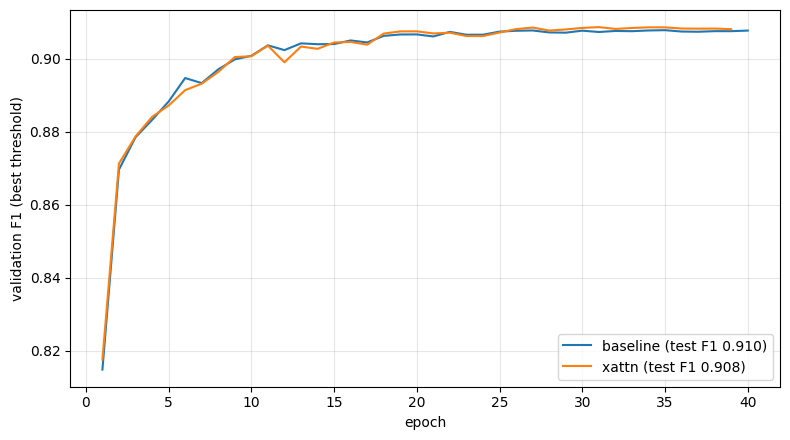

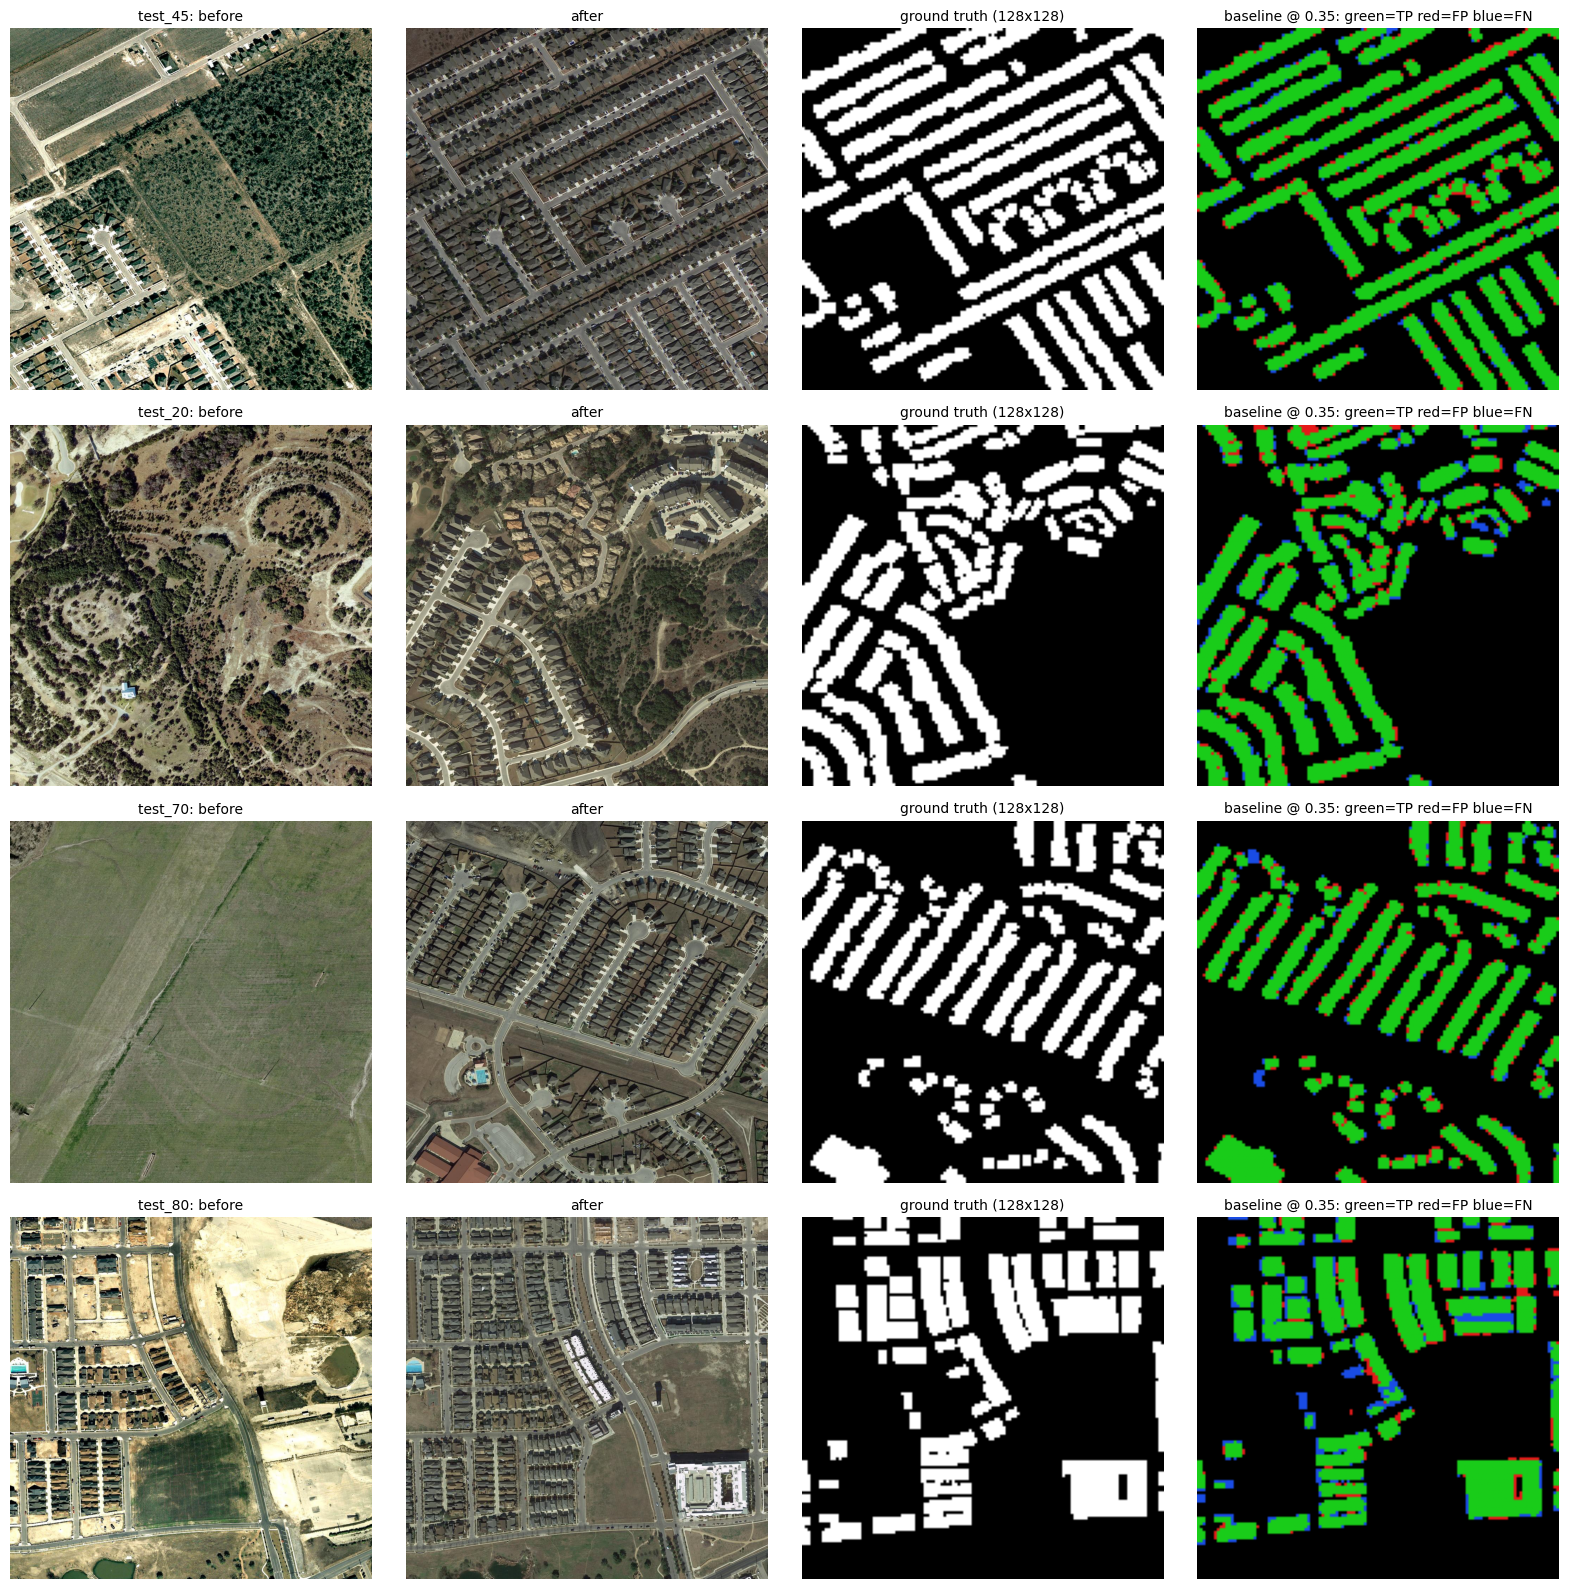

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for variant, h in histories.items():
    ax.plot(h["epoch"], h["val_f1"], label=f"{variant} (test F1 {results[variant]['test']['f1']:.3f})")
ax.set_xlabel("epoch")
ax.set_ylabel("validation F1 (best threshold)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150)
plt.show()

variant = "baseline"
model, threshold = models[variant], results[variant]["threshold"]
model.eval()
show = sorted(data["test"], key=lambda item: -item["target"].sum().item())[:4]
name_to_pair = {p["name"]: p for p in pairs["test"]}
fig, axes = plt.subplots(len(show), 4, figsize=(16, 4 * len(show)))
for row, item in enumerate(show):
    batch = make_batch([item])
    with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
        prob = torch.sigmoid(model(batch["a"], batch["b"]).float())[0].cpu().numpy()
    target = item["target"].numpy().astype(bool)
    predicted = prob > threshold
    overlay = np.zeros((*target.shape, 3))
    overlay[predicted & target] = [0.1, 0.8, 0.1]
    overlay[predicted & ~target] = [0.9, 0.1, 0.1]
    overlay[~predicted & target] = [0.1, 0.3, 0.9]
    p = name_to_pair[item["name"]]
    panels = [(Image.open(p["a"]), f"{item['name']}: before"), (Image.open(p["b"]), "after"),
              (target, "ground truth (128x128)"), (overlay, f"{variant} @ {threshold:.2f}: green=TP red=FP blue=FN")]
    for col, (image, title) in enumerate(panels):
        axes[row, col].imshow(image, cmap="gray" if col == 2 else None)
        axes[row, col].set_title(title, fontsize=10)
        axes[row, col].axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "test_predictions.png", dpi=120)
plt.show()